In [2]:
import os

# Configurer le token Kaggle directement
os.environ["KAGGLE_TOKEN"] = "KGAT_d49388eeb8c06bcea161d9f1d77c74e5"

# Creer le dossier et le fichier access_token
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_d49388eeb8c06bcea161d9f1d77c74e5")

os.chmod("/root/.kaggle/access_token", 0o600)

# Installer kaggle
!pip install kaggle -q

print("Kaggle configure avec succes !")

Kaggle configure avec succes !


In [3]:
# Telecharger le dataset RX thorax
!kaggle datasets download \
  -d paultimothymooney/chest-xray-pneumonia \
  --unzip -p /content/chest_xray

print("Dataset telecharge !")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:52<00:00, 21.9MB/s]

Dataset telecharge !


In [4]:
import os

# Verifier la structure du dataset
for root, dirs, files in os.walk("/content/chest_xray"):
    level = root.replace("/content/chest_xray", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:
            print(f"{subindent}{file}")
        if len(files) > 3:
            print(f"{subindent}... ({len(files)} fichiers total)")

chest_xray/
  chest_xray/
    test/
      NORMAL/
      PNEUMONIA/
    chest_xray/
      test/
        NORMAL/
        PNEUMONIA/
      train/
        NORMAL/
        PNEUMONIA/
      val/
        NORMAL/
        PNEUMONIA/
    __MACOSX/
      chest_xray/
        test/
          NORMAL/
          PNEUMONIA/
        train/
          NORMAL/
          PNEUMONIA/
        val/
          NORMAL/
          PNEUMONIA/
    train/
      NORMAL/
      PNEUMONIA/
    val/
      NORMAL/
      PNEUMONIA/


In [5]:
import os

base = "/content/chest_xray/chest_xray"

for split in ["train", "val", "test"]:
    for classe in ["NORMAL", "PNEUMONIA"]:
        path = f"{base}/{split}/{classe}"
        n = len(os.listdir(path))
        print(f"{split}/{classe} : {n} images")

train/NORMAL : 1341 images
train/PNEUMONIA : 3875 images
val/NORMAL : 8 images
val/PNEUMONIA : 8 images
test/NORMAL : 234 images
test/PNEUMONIA : 390 images


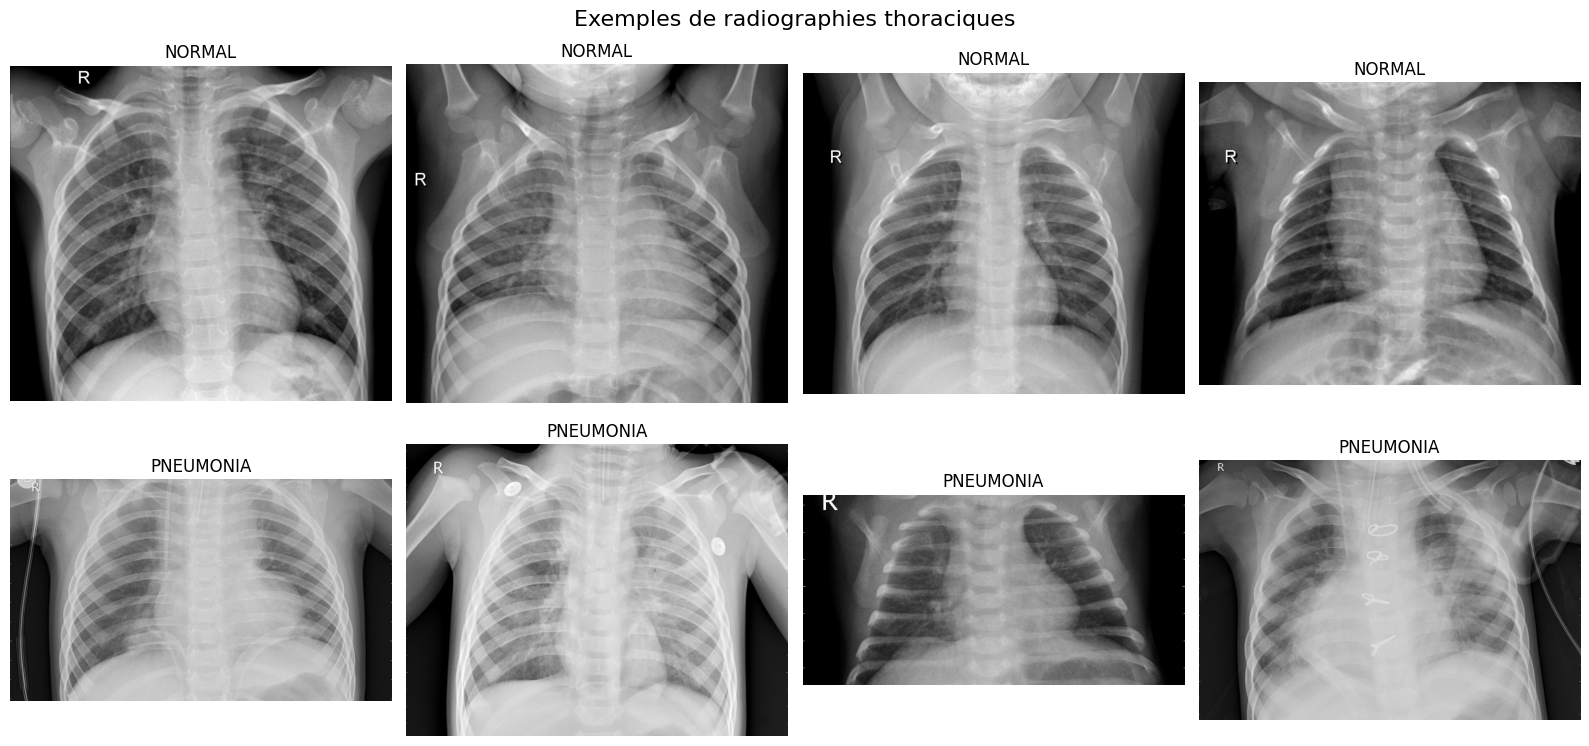

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

base = "/content/chest_xray/chest_xray"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Exemples de radiographies thoraciques", fontsize=16)

for i, classe in enumerate(["NORMAL", "PNEUMONIA"]):
    path = f"{base}/train/{classe}"
    images = random.sample(os.listdir(path), 4)
    for j, img_name in enumerate(images):
        img = mpimg.imread(f"{path}/{img_name}")
        axes[i][j].imshow(img, cmap="gray")
        axes[i][j].set_title(classe)
        axes[i][j].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base = "/content/chest_xray/chest_xray"

# Augmentation des donnees pour le train
# (evite l'overfitting en creant des variations)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalise pixels 0-255 → 0-1
    rotation_range=10,        # rotation aleatoire jusqu'a 10 degres
    zoom_range=0.1,           # zoom aleatoire 10%
    horizontal_flip=True,     # retournement horizontal
    validation_split=0.2      # 20% du train → validation
)

# Test : juste normalisation, pas d'augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Generateur train
train_gen = train_datagen.flow_from_directory(
    f"{base}/train",
    target_size=(224, 224),   # taille standard EfficientNet
    batch_size=32,
    class_mode="binary",      # 0=NORMAL, 1=PNEUMONIA
    subset="training",
    seed=42
)

# Generateur validation
val_gen = train_datagen.flow_from_directory(
    f"{base}/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    seed=42
)

# Generateur test
test_gen = test_datagen.flow_from_directory(
    f"{base}/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False             # important pour l'evaluation
)

print(f"Classes : {train_gen.class_indices}")
print(f"Train : {train_gen.samples} images")
print(f"Val   : {val_gen.samples} images")
print(f"Test  : {test_gen.samples} images")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes : {'NORMAL': 0, 'PNEUMONIA': 1}
Train : 4173 images
Val   : 1043 images
Test  : 624 images


In [8]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

# 1. Charger EfficientNetB0 pre-entraine sur ImageNet
# include_top=False : on retire la derniere couche
# (elle classifiait 1000 classes ImageNet)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Geler les poids du modele pre-entraine
# On ne reentraine pas EfficientNet
# On utilise juste ses features
base_model.trainable = False

# 3. Ajouter nos propres couches de classification
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # sortie binaire
])

# 4. Compiler le modele
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc")]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# Callbacks pour optimiser l'entrainement
callbacks = [
    # Arrete si val_auc ne s'ameliore plus apres 5 epochs
    EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max"
    ),
    # Reduit le learning rate si stagnation
    ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=3,
        mode="max",
        verbose=1
    ),
    # Sauvegarde le meilleur modele
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

# Entrainement
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("Entrainement termine !")

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.6830 - auc: 0.4908 - loss: 0.7101
Epoch 1: val_auc improved from None to 0.55586, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.6887 - auc: 0.5031 - loss: 0.6968 - val_accuracy: 0.7430 - val_auc: 0.5559 - val_loss: 0.5996 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6917 - auc: 0.4943 - loss: 0.6659
Epoch 2: val_auc improved from 0.55586 to 0.66681, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 754ms/step - accuracy: 0.7115 - auc: 0.5092 - loss: 0.6351 - val_accuracy: 0.7430 - val_auc: 0.6668 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7328 - auc: 0.5252 - loss: 0.5994
Epoch 3: val_auc did not improve from 0.66681
131/131 ━━━━━━━━━━━━━━━━━━━━ 

Evaluation sur le jeu de test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 826ms/step - accuracy: 0.6250 - auc: 0.8104 - loss: 0.6364

Test Accuracy : 0.625
Test AUC      : 0.810
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 527ms/step

Classification Report :
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


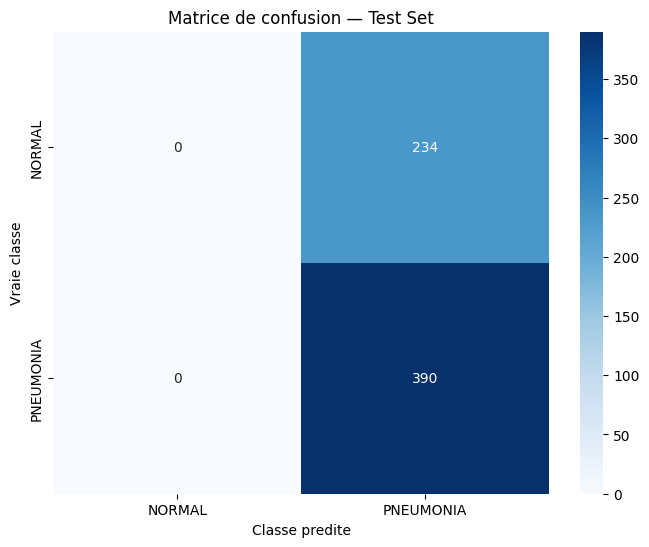


AUC-ROC final : 0.811


In [ ]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation sur le test set
print("Evaluation sur le jeu de test...")
results = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {results[1]:.3f}")
print(f"Test AUC      : {results[2]:.3f}")

# Predictions
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Classification report
print("\nClassification Report :")
print(classification_report(
    y_true, y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
    cmap="Blues"
)
plt.title("Matrice de confusion — Test Set")
plt.ylabel("Vraie classe")
plt.xlabel("Classe predite")
plt.show()

print(f"\nAUC-ROC final : {roc_auc_score(y_true, y_pred_proba):.3f}")

In [ ]:
# Cellule 10 — Trouver le meilleur seuil
from sklearn.metrics import roc_curve
import numpy as np

y_pred_proba = model.predict(test_gen).flatten()
y_true = test_gen.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

# Trouver le seuil optimal (maximise TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil optimal : {optimal_threshold:.3f}")

# Appliquer le nouveau seuil
y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)

print("\nClassification Report avec seuil optimal :")
from sklearn.metrics import classification_report
print(classification_report(
    y_true, y_pred_optimal,
    target_names=["NORMAL", "PNEUMONIA"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step
Seuil optimal : 0.688

Classification Report avec seuil optimal :
              precision    recall  f1-score   support

      NORMAL       0.64      0.71      0.67       234
   PNEUMONIA       0.81      0.76      0.78       390

    accuracy                           0.74       624
   macro avg       0.72      0.73      0.73       624
weighted avg       0.75      0.74      0.74       624



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculer les poids de classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_gen.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights : {class_weight_dict}")
# NORMAL aura un poids plus eleve
# car il est minoritaire (26% vs 74%)

# Reenttrainer avec class weights
print("\nReentrainement avec class weights...")
history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("Termine !")